In [1]:
from Montreal_UHI_toolbox import *

In [2]:
from sklearn.linear_model import LinearRegression

In [3]:
path = '/runoff/gulley/St_Laurent/intermediates/station' # move tasmin to /runoff/gulley/St_Laurent/intermediates/station
avgs = {}
stds = {}
for field in ['tasmax','tas','tasmin']:
    avgs[field] = xr.open_zarr(f'{path}/seasons_avg_{field}.zarr')
    stds[field] = xr.open_zarr(f'{path}/seasons_std_{field}.zarr')
    

In [4]:
for static_field in TEB_geophys: 
    if 'lev' in static_field.coords:
        static_field = static_field.sel(lev=1) # All levels are identical in the TEB fields so I'll just take the first
    for field in ['tasmax','tas','tasmin']:
        static_field = static_field.rename(f'{static_field.name}_TEB')
        avgs[field] = add_blurred_field_to_stations(static_field,sigma=1.5,stations=avgs[field])
        stds[field] = add_field_to_stations(static_field,stations=stds[field])

In [5]:
# Add TEB fields to 
for lev in veg_levs:
    static_field = veg_fields.sel(lev=lev).rename(veg_levs[lev])
    for field in ['tasmax','tas','tasmin']:
        avgs[field] = add_blurred_field_to_stations(static_field,sigma=1.5,stations=avgs[field])
        avgs[field] = add_field_to_stations(static_field,stations=avgs[field])

In [6]:
# Forgot to include elevation as a coordinate, and this may be pertinent in the regression
for field in ['tasmax','tas','tasmin']:
    avgs[field] = avgs[field].assign_coords({'elev': stations.elev})
    stds[field] = stds[field].assign_coords({'elev': stations.elev})

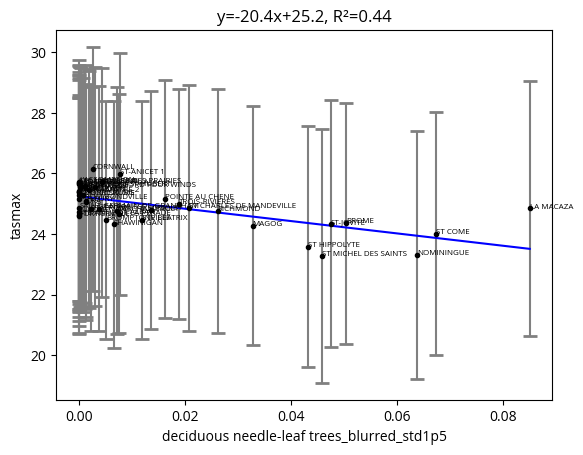

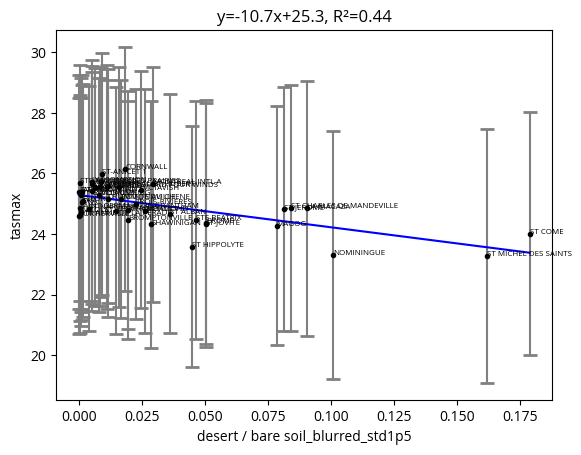

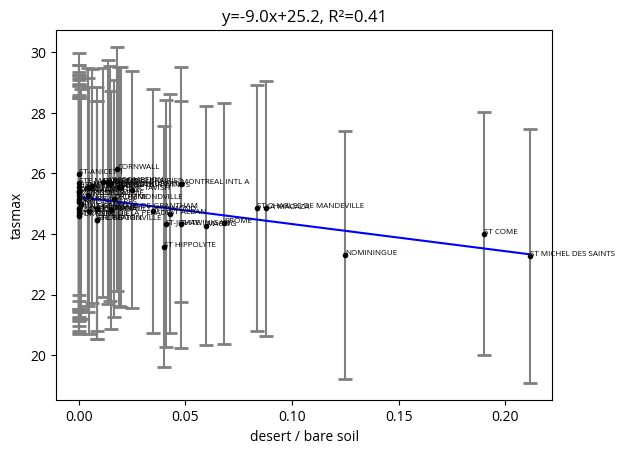

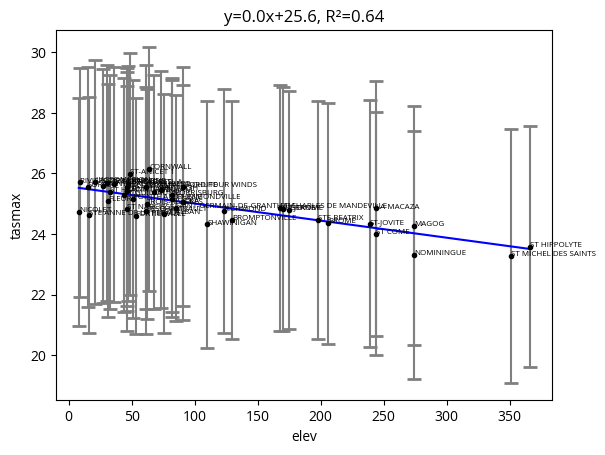

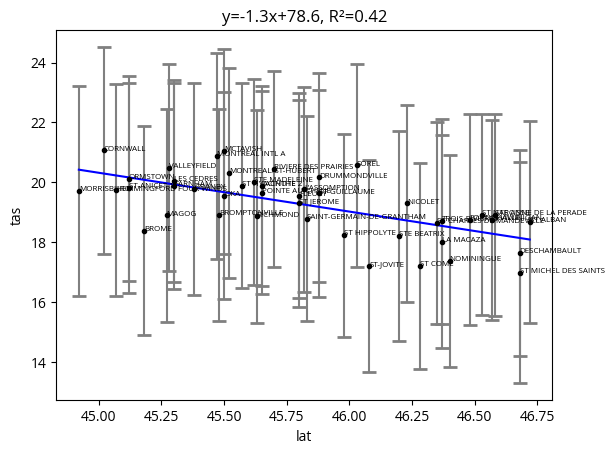

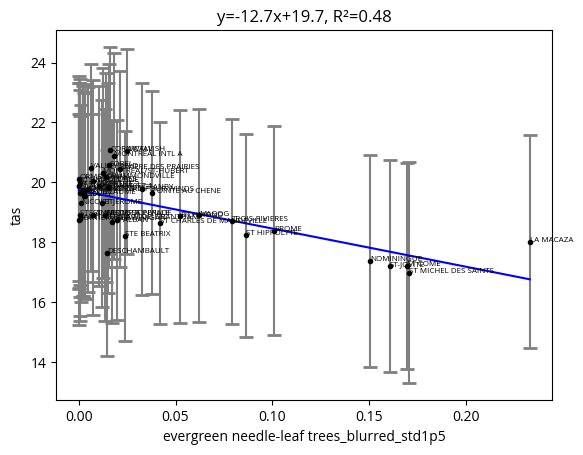

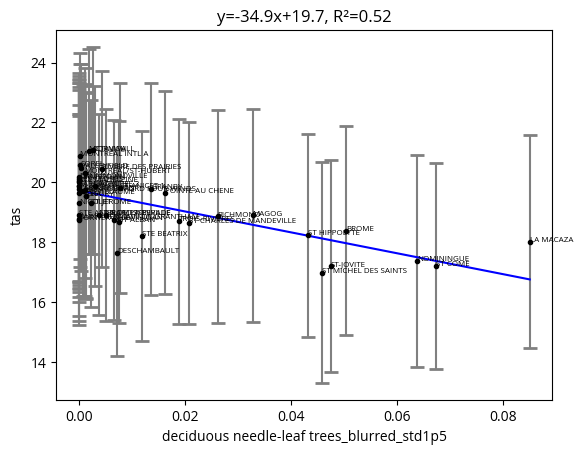

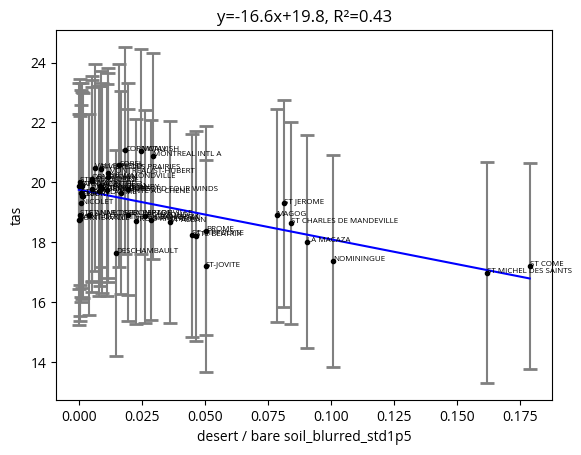

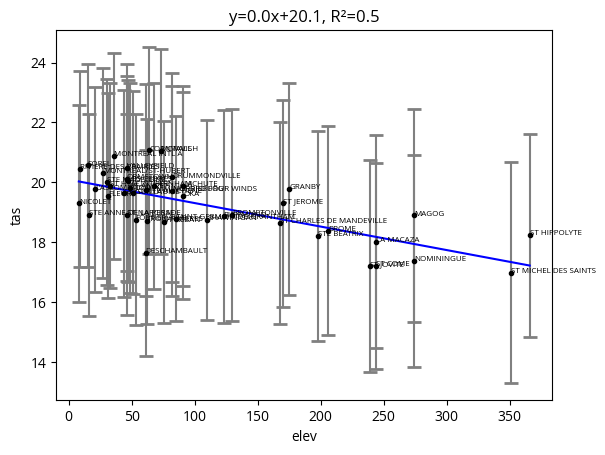

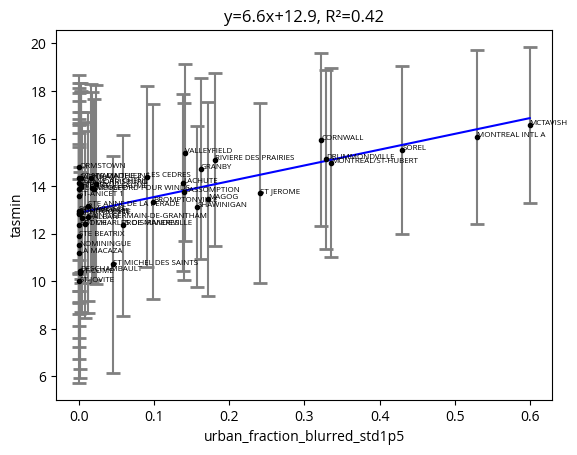

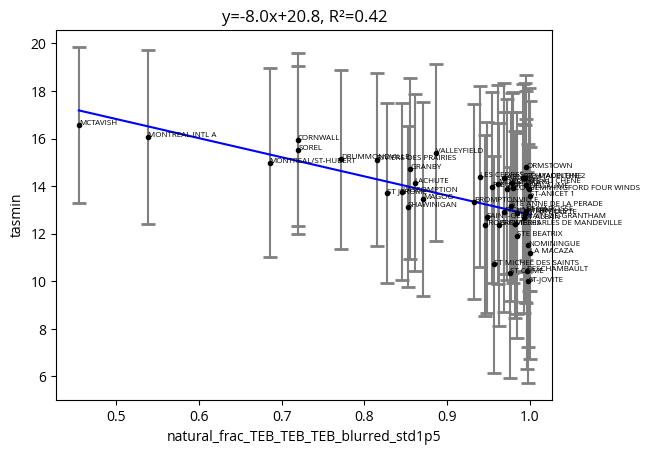

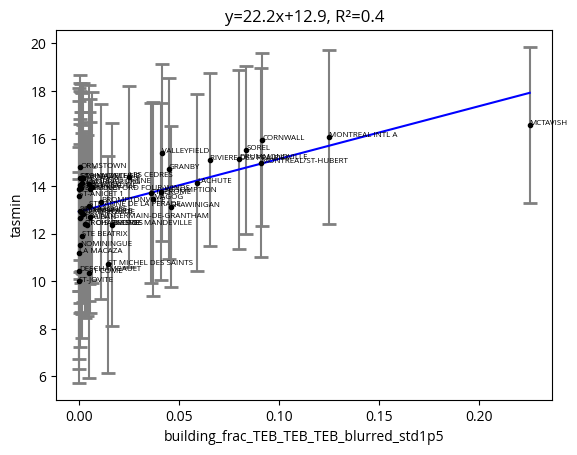

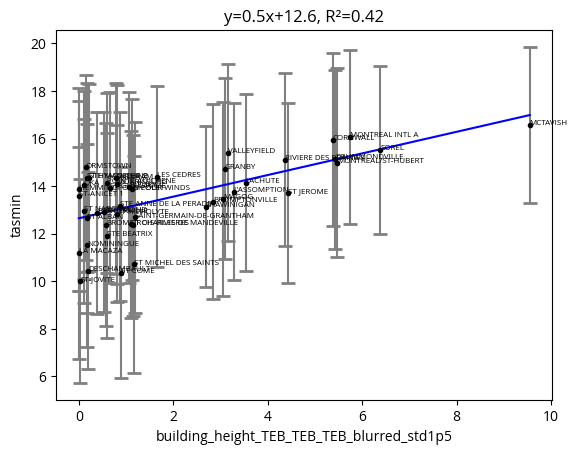

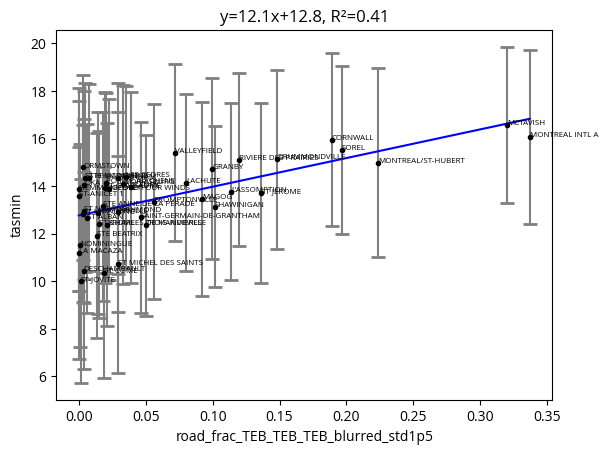

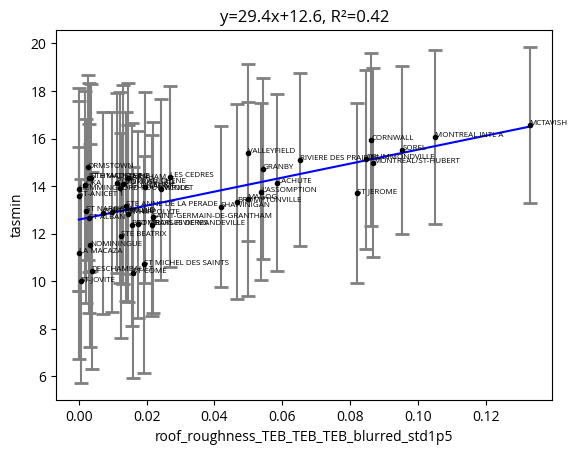

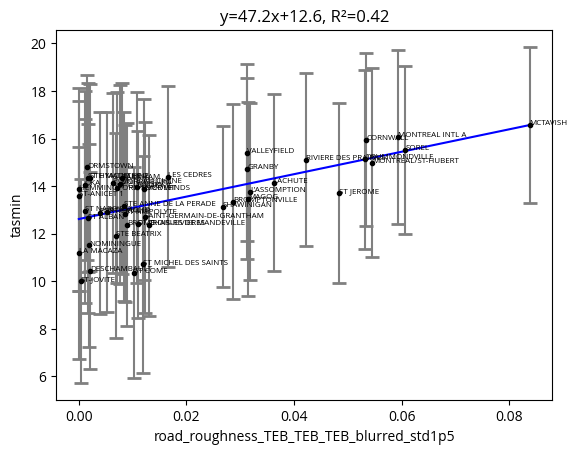

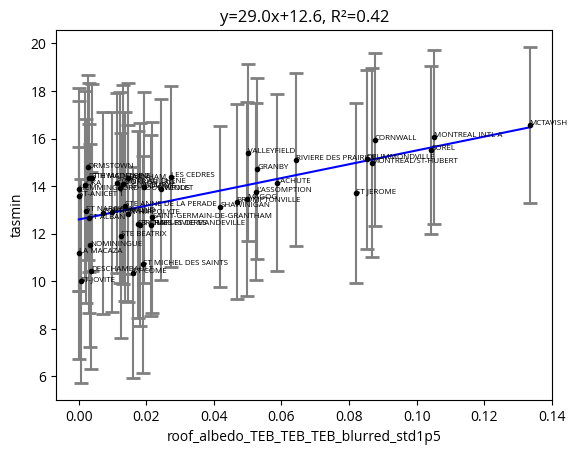

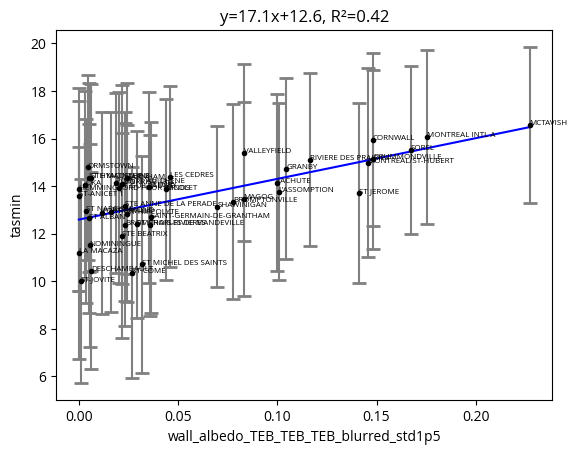

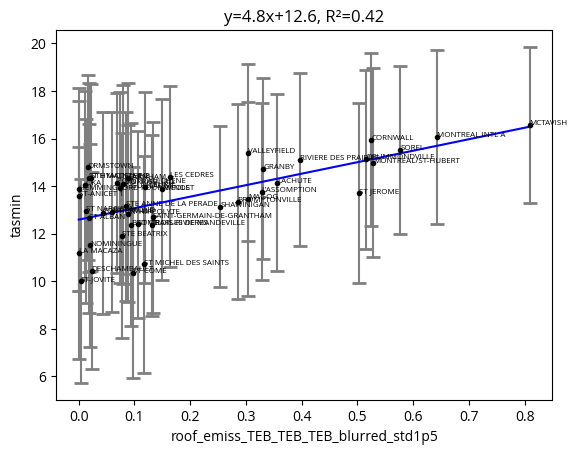

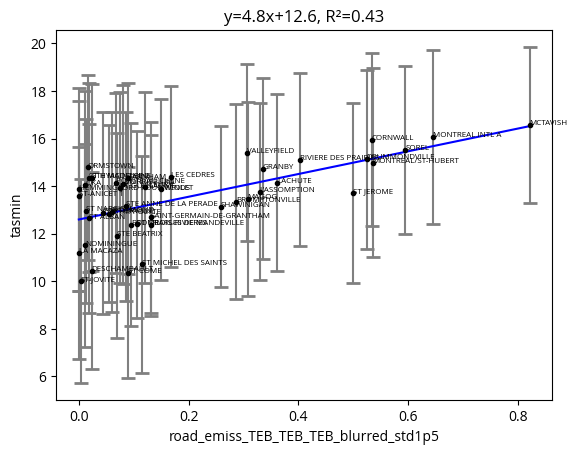

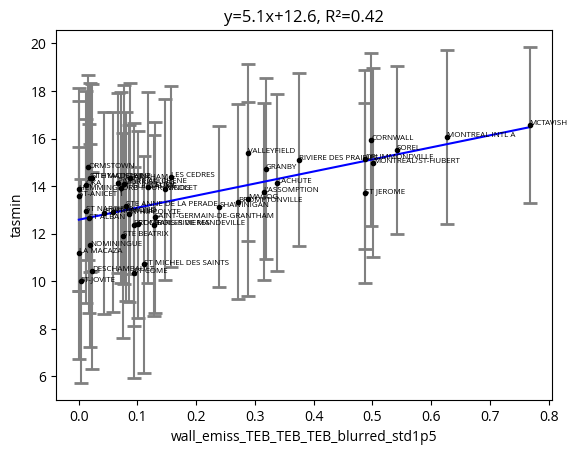

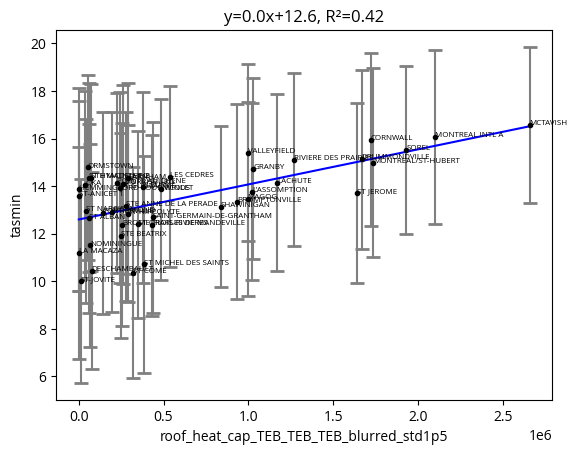

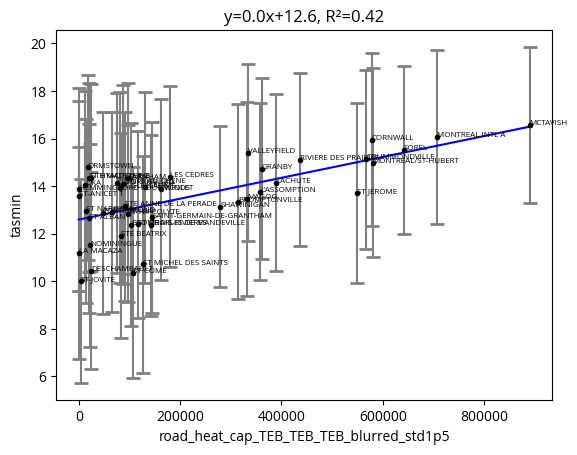

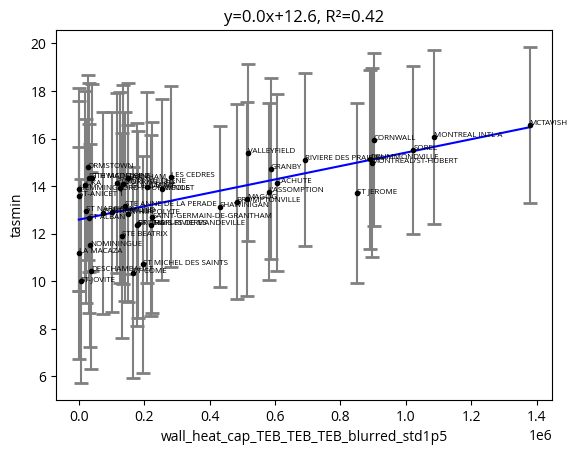

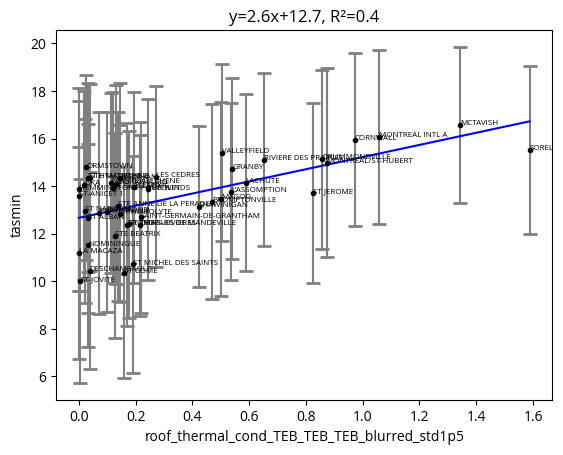

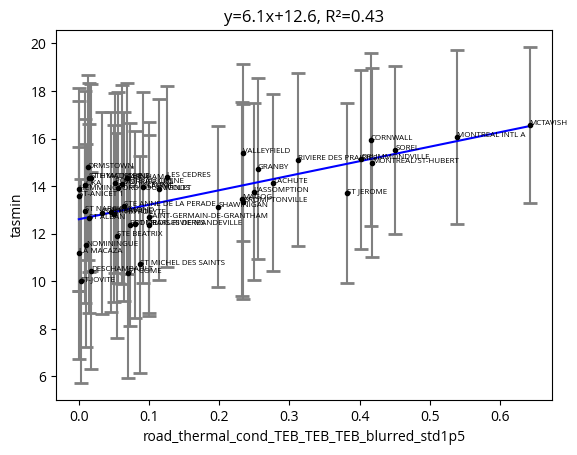

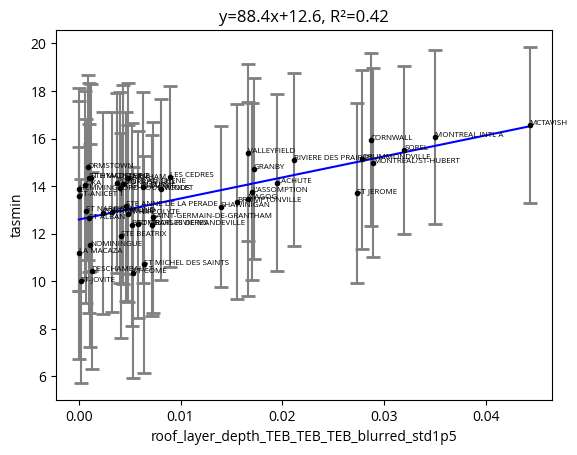

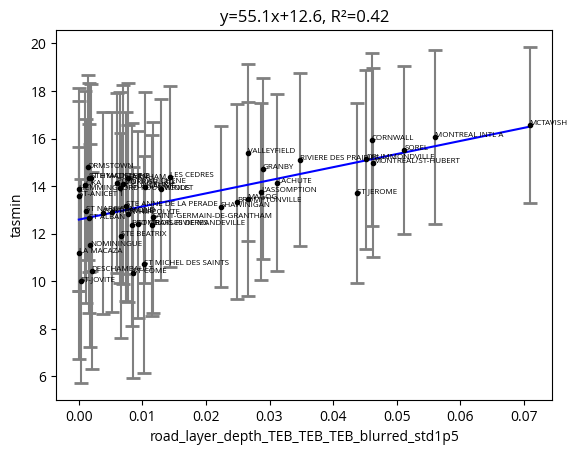

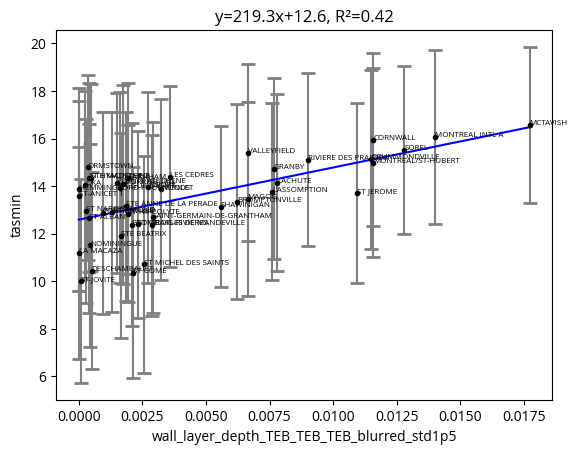

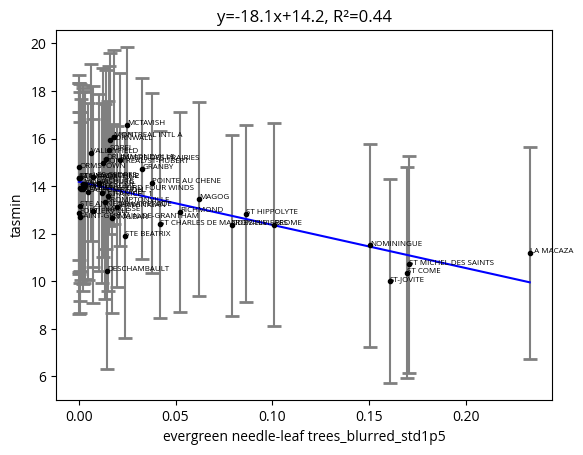

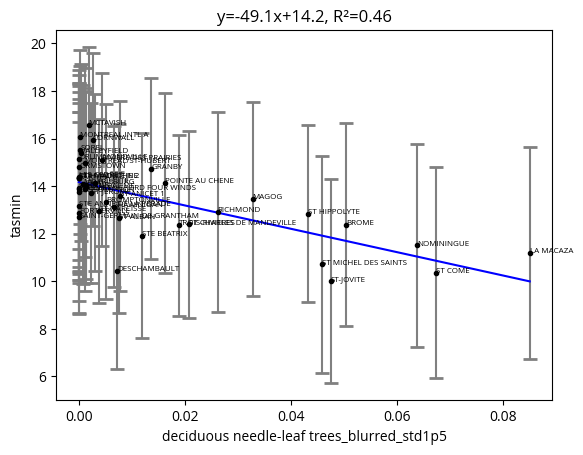

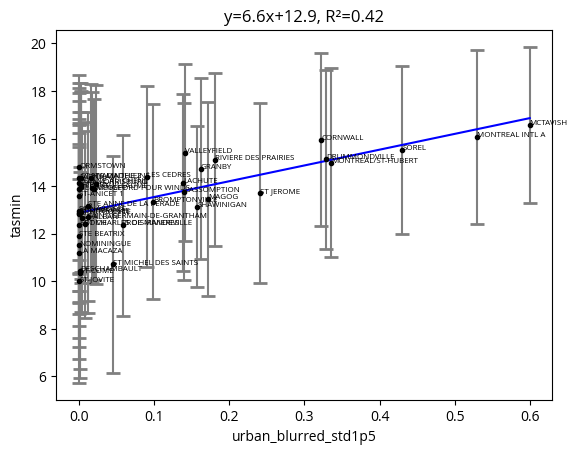

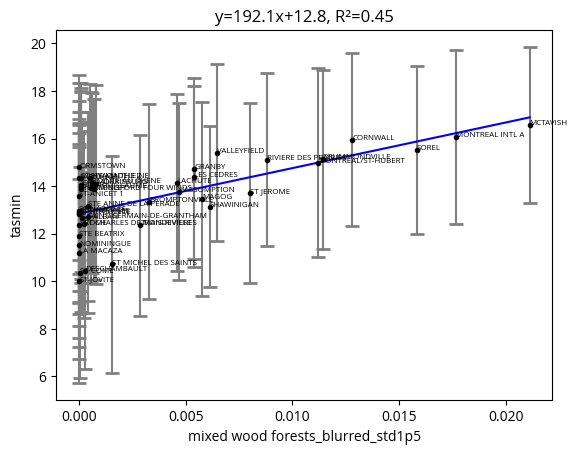

In [25]:
season = 'JJA'

for field in ['tasmax','tas','tasmin']:
    data = avgs[field].dropna(dim='station').sel(season=season)
    errs = stds[field].dropna(dim='station').sel(season=season)
    for coords in data.coords:
        x = data[coords].values
        y = data[field].values
        names = list(data['station_name'].values)
        yerr = errs[field]
        
        if(np.shape(x) == np.shape(y) and (data[coords].dtype == 'float64' or data[coords].dtype == 'float32')):
            model = LinearRegression()
            X = x.reshape(-1, 1)
            model.fit(X,y)
            r_square = model.score(X,y)
            if r_square >= 0.4: # Ignore weakest linear correlations            
                
                # plt.title(season)
                plt.ylabel(field)
                plt.xlabel(coords)
                
                # plt.plot(x,y,'.',color='black',label=field)
                plt.errorbar(x, y, yerr=yerr, fmt='.',color='black', ecolor='gray', capsize=5, capthick=2)
                
                xline = np.linspace(min(x),max(x),2)
                yline = xline*model.coef_ + model.intercept_
                plt.plot(xline,yline,'b')
                plt.title(f'y={round(model.coef_[0]*10)/10}x+{round(model.intercept_*10)/10}, R²={round(r_square*100)/100}')
                for x_pos,y_pos,stn_name in zip (x,y,names):
                    plt.text(x_pos, y_pos, stn_name,size='xx-small')
            plt.show()

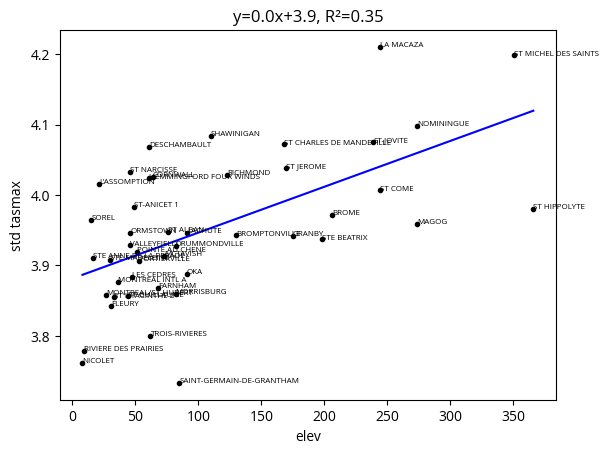

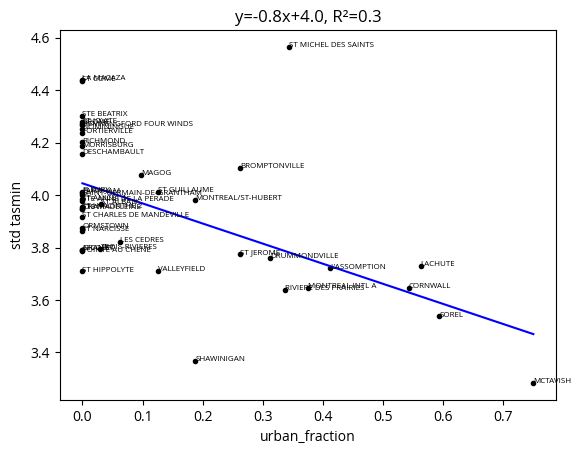

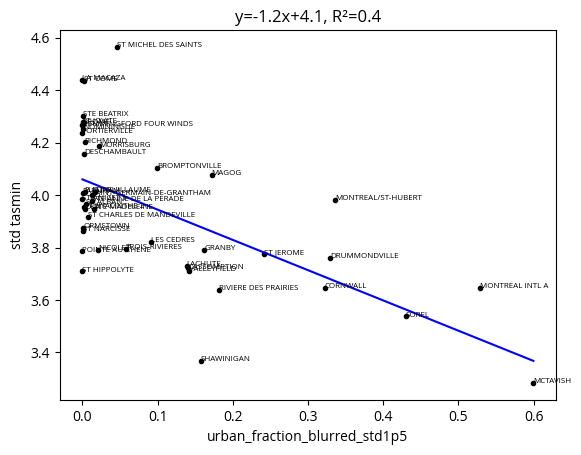

In [24]:
season = 'JJA'
for field in ['tasmax','tas','tasmin']:
    data = stds[field].dropna(dim='station').sel(season=season)
    for coords in data.coords:
        x = data[coords].values
        y = data[field].values
        names = list(data['station_name'].values)
        
        if(np.shape(x) == np.shape(y) and (data[coords].dtype == 'float64' or data[coords].dtype == 'float32')):

            model = LinearRegression()
            X = x.reshape(-1, 1)
            model.fit(X,y)
            r_square = model.score(X,y)
            if r_square >= 0.3: # Ignore weakest linear correlations          
                plt.ylabel(f'std {field}')
                plt.xlabel(coords)
                plt.plot(x,y,'.',color='black',label=field)
    
                xline = np.linspace(min(x),max(x),2)
                yline = xline*model.coef_ + model.intercept_
                plt.plot(xline,yline,'b')
                plt.title(f'y={round(model.coef_[0]*10)/10}x+{round(model.intercept_*10)/10}, R²={round(r_square*100)/100}')
                for x_pos,y_pos,stn_name in zip (x,y,names):
                    plt.text(x_pos, y_pos, stn_name,size='xx-small')
            plt.show()

In [33]:
avgs['tasmin'].sortby()

ValueError: Dimensions {'tasmin'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'station': 49, 'season': 4})

In [36]:
a = avgs['tasmin'].sel(season= 'JJA')

In [42]:
a.sortby(a.tasmin,ascending=False).tasmin.dropna(dim='station').values

array([16.56933781, 16.06669825, 15.95433333, 15.5268685 , 15.40570934,
       15.1305026 , 15.11541522, 14.9907153 , 14.78610057, 14.74153922,
       14.40547739, 14.36356932, 14.36173261, 14.3225924 , 14.15375887,
       14.12116883, 14.08585248, 14.04265809, 13.95496755, 13.93153951,
       13.86679555, 13.86001009, 13.76469183, 13.71993688, 13.59387755,
       13.46415289, 13.35051659, 13.1602451 , 13.14375   , 12.95592537,
       12.93139478, 12.87219171, 12.8436721 , 12.68626677, 12.64443898,
       12.3909585 , 12.38821705, 12.3564347 , 11.92248954, 11.50938596,
       11.18808945, 10.71123529, 10.44887033, 10.35912791, 10.00540929])

In [41]:
a.sortby(a.tasmin,ascending=False).station_name.dropna(dim='station').values

array(['HUBERDEAU', 'MACDONALD COLLEGE', 'ST TITE', 'BERTHIERVILLE',
       'MCTAVISH', 'MONTREAL INTL A', 'CORNWALL', 'SOREL', 'VALLEYFIELD',
       'DRUMMONDVILLE', 'RIVIERE DES PRAIRIES', 'MONTREAL/ST-HUBERT',
       'ORMSTOWN', 'GRANBY', 'LES CEDRES', 'ST HYACINTHE 2',
       'STE MADELEINE', 'FARNHAM', 'LACHUTE', 'POINTE AU CHENE',
       'MORRISBURG', 'OKA', 'FLEURY', 'ST GUILLAUME',
       'HEMMINGFORD FOUR WINDS', 'NICOLET', "L'ASSOMPTION", 'ST JEROME',
       'ST-ANICET 1', 'MAGOG', 'BROMPTONVILLE', 'STE ANNE DE LA PERADE',
       'SHAWINIGAN', 'ST NARCISSE', 'RICHMOND', 'FORTIERVILLE',
       'ST HIPPOLYTE', 'SAINT-GERMAIN-DE-GRANTHAM', 'ST ALBAN',
       'ST CHARLES DE MANDEVILLE', 'BROME', 'TROIS-RIVIERES',
       'STE BEATRIX', 'NOMININGUE', 'LA MACAZA', 'ST MICHEL DES SAINTS',
       'DESCHAMBAULT', 'ST COME', 'ST-JOVITE'], dtype=object)